# 00 · The big picture

**Series:** the Transformer, one concept per notebook. Read in order (00 → 11).

Strip away the jargon and an LLM does ONE thing: read a sequence of tokens and **predict the
next token**. Feed each prediction back in and it writes whole paragraphs — this is called
**autoregressive** generation.

```
"The cat sat"  ─►  P(next):  "on" 0.72   "down" 0.11   "there" 0.05  ...
      ▲                                    │
      └──────────── append "on" ◄──────────┘   then predict again: "The cat sat on ___"
```

Everything in this series answers: *how do we turn "The cat sat" into a good guess for "on"?*

### The full pipeline (what we'll build, notebook by notebook)
```
text ─► tokenize(01) ─► embed(02) + position(03)
     ─► [ attention(04,05,06) ─► feed-forward(07) , with residual+norm(08) ] × N   (09)
     ─► output head ─► softmax ─► next-token probability                            (10)
```

## The one tool used everywhere: `softmax`

`softmax` turns any list of raw scores into **probabilities** (each in 0..1, summing to 1).
It appears twice: inside attention (to split "how much to look at each token") and at the
very end (to pick the next token). Let's implement it once.

In [ ]:
import math

# This version not using numpy
def softmax_native(z):
  exp_values = []
  for i in z:
    exp_values.append(math.exp(i)) # exponentiate each value

  sum_exp_values = sum(exp_values) # sum of all the exponentials
  probabilities = []

  for value in exp_values:
    probabilities.append(value / sum_exp_values)

  return probabilities

z = [2.0, 1.0, 0.1]
print(softmax_native(z))

[0.6590011388859679, 0.2424329707047139, 0.09856589040931818]


In [1]:
import numpy as np
np.random.seed(0)                      # reproducible: same numbers every run

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)   # subtract max -> stops exp() overflow (safe, same result)
    e = np.exp(x)                             # exp is always positive AND magnifies gaps
    return e / e.sum(axis=axis, keepdims=True)  # normalize so the row sums to 1

scores = np.array([2.0, 1.0, 0.1])
p = softmax(scores)
print("scores      :", scores)
print("probabilities:", p.round(3), " sum =", round(p.sum(), 6))
assert np.isclose(p.sum(), 1.0)

scores      : [2.  1.  0.1]
probabilities: [0.659 0.242 0.099]  sum = 1.0


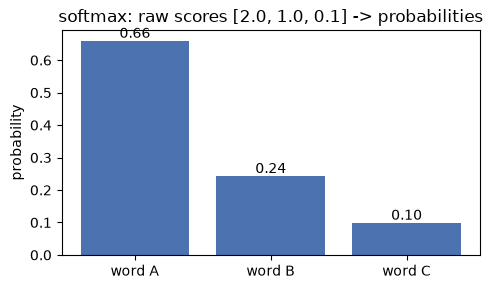

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["word A", "word B", "word C"], p, color="#4C72B0")
ax.set_title("softmax: raw scores [2.0, 1.0, 0.1] -> probabilities")
ax.set_ylabel("probability")
for i, v in enumerate(p):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()

**Takeaway.** The model is a next-token predictor. `softmax` is the little engine that turns
scores into probabilities — remember it, we reuse it everywhere. Next: **01 · tokenization**.